In [0]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from skimage import data, transform
from scipy.ndimage import gaussian_filter
import json

np.random.seed(0)
plt.rcParams['figure.dpi'] = 110

# =============================================================================
# CANONICAL PARAMETER BLOCK — single source of truth for the whole notebook
# =============================================================================
# All lengths in micrometers (um) unless stated otherwise.
WAVELENGTH_UM   = 0.532      # 532 nm, matches the notebook code (report cites 0.539 um -- flagged)
MAG             = 2.0        # system magnification
CAM_PIXEL_UM    = 2.5        # physical camera pixel pitch
EFF_PIXEL_UM    = CAM_PIXEL_UM / MAG   # effective pixel size at the object plane

N_LR            = 128        # simulated low-res (captured) grid size
DS              = 4          # oversampling factor for the high-res "ground truth" field
N_HR            = N_LR * DS  # high-res simulation grid
HR_PIXEL_UM     = EFF_PIXEL_UM / DS

# Single canonical defocus sweep used everywhere unless a section explicitly studies range/resolution.
# +/- 50 um is physically generous for a low-NA FPM system and matches typical defocus magnitudes
# reported in the FPM literature (Zheng et al. 2013; Sun et al. 2004).
Z_RANGE_UM      = 50.0
Z_STEPS         = 161
Z_ARRAY_UM      = np.linspace(-Z_RANGE_UM, Z_RANGE_UM, Z_STEPS)

# Canonical NA sweep. NA=1.50 from the original notebook is not physically meaningful for a dry
# objective (removed); replaced with a sensible dry-objective range plus one high-NA case.
NA_LIST = [0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.40, 0.60]

print("Canonical parameters")
print(f"  wavelength        = {WAVELENGTH_UM} um")
print(f"  camera pixel      = {CAM_PIXEL_UM} um  (effective @ object plane = {EFF_PIXEL_UM:.3f} um)")
print(f"  N_LR / N_HR       = {N_LR} / {N_HR}  (oversampling ds = {DS})")
print(f"  camera Nyquist    = {1/(2*EFF_PIXEL_UM):.3f} 1/um")
print(f"  defocus sweep     = +/-{Z_RANGE_UM} um, {Z_STEPS} steps")
print(f"  NA sweep          = {NA_LIST}")

Canonical parameters
  wavelength        = 0.532 um
  camera pixel      = 2.5 um  (effective @ object plane = 1.250 um)
  N_LR / N_HR       = 128 / 512  (oversampling ds = 4)
  camera Nyquist    = 0.400 1/um
  defocus sweep     = +/-50.0 um, 161 steps
  NA sweep          = [0.05, 0.08, 0.1, 0.15, 0.2, 0.25, 0.4, 0.6]


## 1. Test objects

Same physical model as the original work: $O = A \cdot e^{i \varphi \cdot c}$, with amplitude
from the standard `cameraman` image and phase from a Gaussian-smoothed `moon` image. The phase
scale constant `c` is still a somewhat arbitrary knob rather than a real refractive-index x
thickness product — flagged here rather than hidden, since it matters for how "weak" vs "strong"
is defined physically.

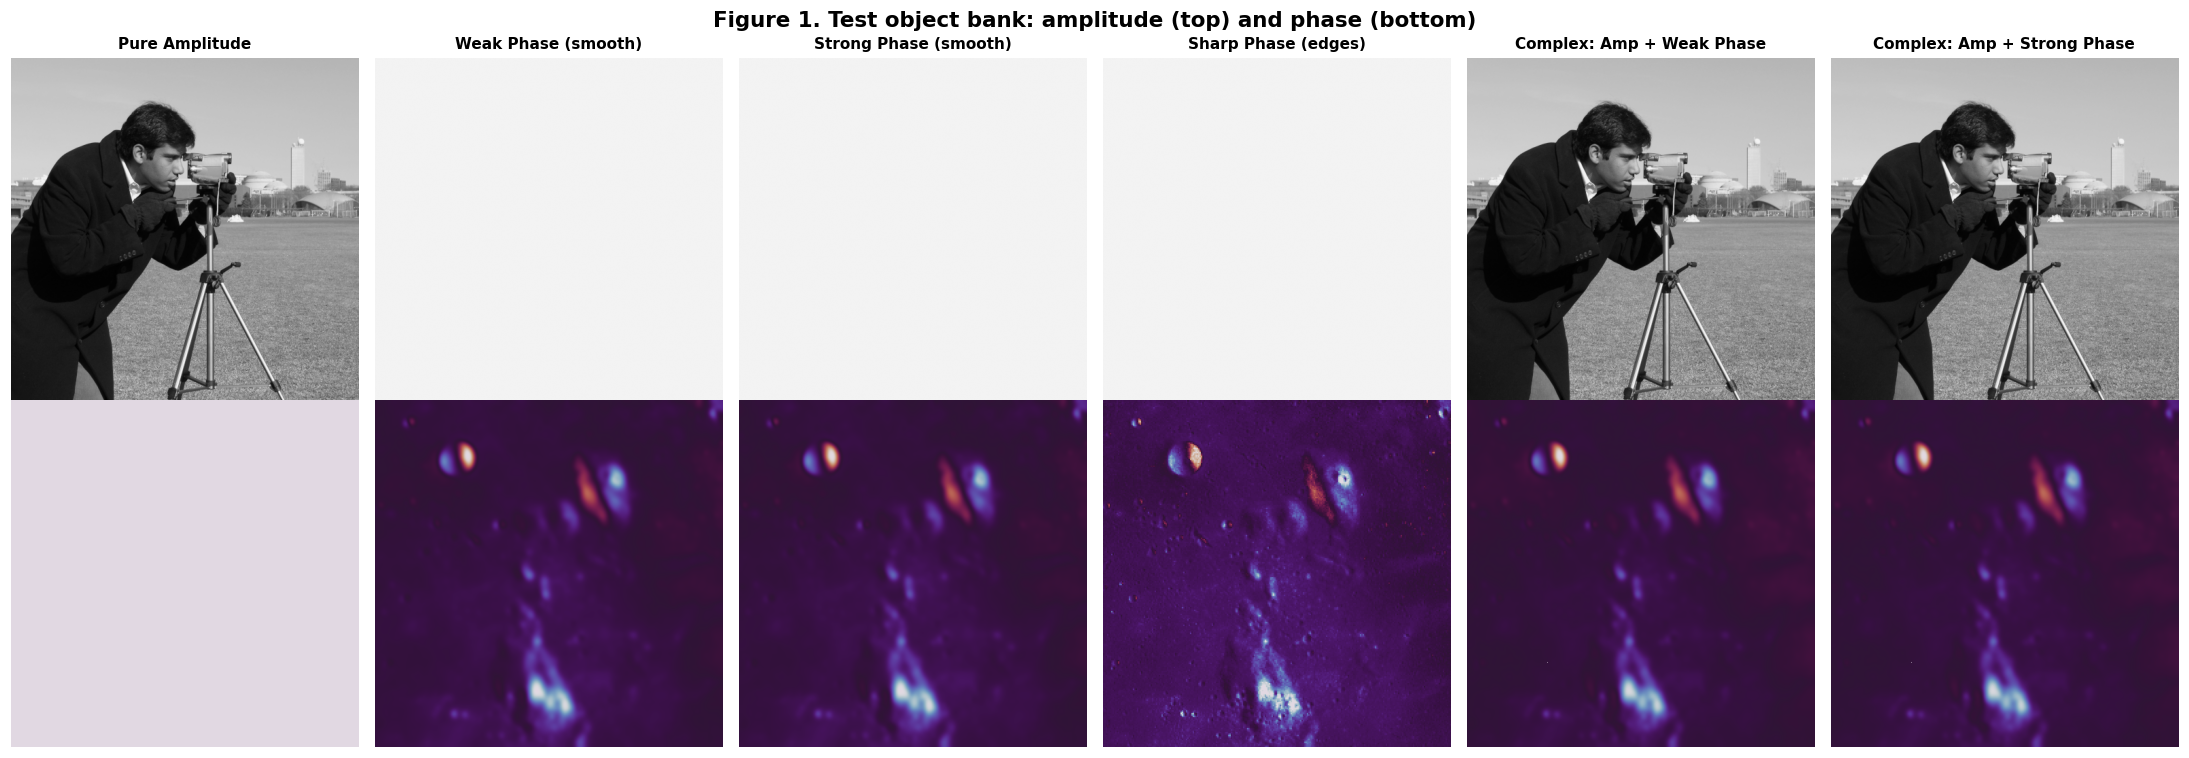

In [2]:
def make_objects(N):
    img_amp = transform.resize(data.camera(), (N, N), anti_aliasing=True)
    img_amp = img_amp / np.max(img_amp)

    img_phase_raw = transform.resize(data.moon(), (N, N), anti_aliasing=True)
    img_phase_smooth = gaussian_filter(img_phase_raw, sigma=4)
    img_phase_smooth = img_phase_smooth / np.max(img_phase_smooth)
    img_phase_sharp = img_phase_raw / np.max(img_phase_raw)

    objects = {
        "Pure Amplitude":            img_amp * np.exp(1j * np.zeros_like(img_amp)),
        "Weak Phase (smooth)":       np.ones((N, N)) * np.exp(1j * (img_phase_smooth * 0.05)),
        "Strong Phase (smooth)":     np.ones((N, N)) * np.exp(1j * (img_phase_smooth * 1.5)),
        "Sharp Phase (edges)":       np.ones((N, N)) * np.exp(1j * (img_phase_sharp * 0.5)),
        "Complex: Amp + Weak Phase": img_amp * np.exp(1j * (img_phase_smooth * 0.5)),
        "Complex: Amp + Strong Phase": img_amp * np.exp(1j * (img_phase_smooth * 3.0)),
    }
    return objects

objects_hr = make_objects(N_HR)
object_names = list(objects_hr.keys())
colors = ['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e', '#9467bd', '#8c564b']

fig, axes = plt.subplots(2, 6, figsize=(20, 7))
for i, (name, obj) in enumerate(objects_hr.items()):
    axes[0, i].imshow(np.abs(obj), cmap='gray', vmin=0, vmax=1.05)
    axes[0, i].set_title(name, fontsize=10, fontweight='bold')
    axes[0, i].axis('off')
    im = axes[1, i].imshow(np.angle(obj), cmap='twilight')
    axes[1, i].axis('off')
axes[0, 0].set_ylabel("Amplitude", fontsize=11)
axes[1, 0].set_ylabel("Phase", fontsize=11)
fig.suptitle("Figure 1. Test object bank: amplitude (top) and phase (bottom)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("figs/fig1_test_objects.png", dpi=150, bbox_inches='tight')
plt.show()

## 2. Angular-spectrum propagator and pupil apertures

Same efficient technique as the original notebook: FFT the full-resolution object once, then crop
the central `N_LR x N_LR` region of the spectrum and apply the pupil/defocus phase there. This is
mathematically valid **only** because `N_HR = N_LR * DS` and `HR_PIXEL = EFF_PIXEL / DS` exactly —
that consistency is now enforced by the canonical parameter block instead of being repeated
(and risking drift) in every cell.

NA values whose pupil radius EXCEEDS the camera Nyquist box (aliasing-prone regime):
  NA=0.05  pupil radius=0.094 1/um
  NA=0.08  pupil radius=0.150 1/um
  NA=0.1   pupil radius=0.188 1/um
  NA=0.15  pupil radius=0.282 1/um
  NA=0.2   pupil radius=0.376 1/um
  NA=0.25  pupil radius=0.470 1/um  <-- pupil wider than camera Nyquist box
  NA=0.4   pupil radius=0.752 1/um  <-- pupil wider than camera Nyquist box
  NA=0.6   pupil radius=1.128 1/um  <-- pupil wider than camera Nyquist box


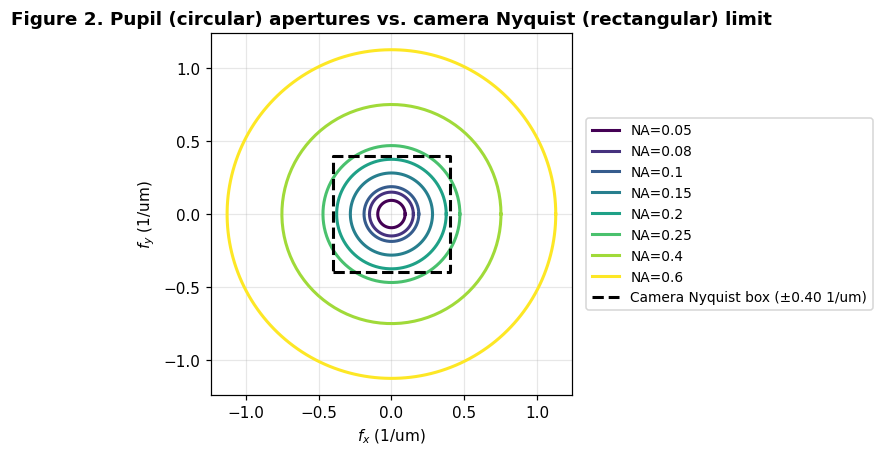

In [4]:
fx_lr = np.fft.fftshift(np.fft.fftfreq(N_LR, d=EFF_PIXEL_UM))
fy_lr = np.fft.fftshift(np.fft.fftfreq(N_LR, d=EFF_PIXEL_UM))
FX_LR, FY_LR = np.meshgrid(fx_lr, fy_lr)
K_RAD_LR = np.sqrt(FX_LR**2 + FY_LR**2)

cy, cx = N_HR // 2, N_HR // 2
ys, ye = cy - N_LR // 2, cy + N_LR // 2
xs, xe = cx - N_LR // 2, cx + N_LR // 2

CAMERA_NYQUIST = 1 / (2 * EFF_PIXEL_UM)

def pupil_and_kz(NA):
    pupil = (K_RAD_LR <= NA / WAVELENGTH_UM).astype(float)
    radicand = np.maximum((1.0 / WAVELENGTH_UM) ** 2 - FX_LR**2 - FY_LR**2, 0.0)
    kz = 2 * np.pi * np.sqrt(radicand)
    return pupil, kz

def propagate_stack(obj, NA, z_array_um):
    """Angular-spectrum defocus sweep. Returns intensity stack (len(z), N_LR, N_LR)."""
    O_fourier = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(obj)))
    O_crop = O_fourier[ys:ye, xs:xe]
    pupil, kz = pupil_and_kz(NA)
    stack = np.empty((len(z_array_um), N_LR, N_LR))
    for i, z in enumerate(z_array_um):
        pupil_z = pupil * np.exp(1j * z * kz)
        E_fourier = O_crop * pupil_z
        E_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_fourier)))
        stack[i] = np.abs(E_spatial) ** 2
    return stack

# Visualize the pupil footprints against the fixed camera-Nyquist (rectangular) box (Figure 6 analogue)
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
pupil_colors = plt.cm.viridis(np.linspace(0, 1, len(NA_LIST)))
for NA, c in zip(NA_LIST, pupil_colors):
    theta = np.linspace(0, 2*np.pi, 200)
    r = NA / WAVELENGTH_UM
    ax.plot(r*np.cos(theta), r*np.sin(theta), color=c, label=f"NA={NA}", linewidth=2)
box = CAMERA_NYQUIST
ax.plot([-box, box, box, -box, -box], [-box, -box, box, box, -box], 'k--', linewidth=2,
        label=f"Camera Nyquist box (±{box:.2f} 1/um)")
ax.set_xlabel("$f_x$ (1/um)"); ax.set_ylabel("$f_y$ (1/um)")
ax.set_title("Figure 2. Pupil (circular) apertures vs. camera Nyquist (rectangular) limit", fontweight='bold')
ax.set_aspect('equal')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figs/fig2_pupil_vs_nyquist.png", dpi=150, bbox_inches='tight')
plt.show()

print("NA values whose pupil radius EXCEEDS the camera Nyquist box (aliasing-prone regime):")
for NA in NA_LIST:
    r = NA / WAVELENGTH_UM
    flag = "  <-- pupil wider than camera Nyquist box" if r > CAMERA_NYQUIST else ""
    print(f"  NA={NA:<5} pupil radius={r:.3f} 1/um{flag}")

## 3. Fourier content of the test objects (why some are "sharper" than others)

Radial power spectral density puts the weak/strong/sharp phase objects on the same axis as the
two physical frequency limits (optical pupil cutoff and camera Nyquist), so we can see directly
which objects have energy sitting in the "collision zone" between the two limits — that's the
regime where clipping artifacts are expected regardless of which specific NA is chosen.

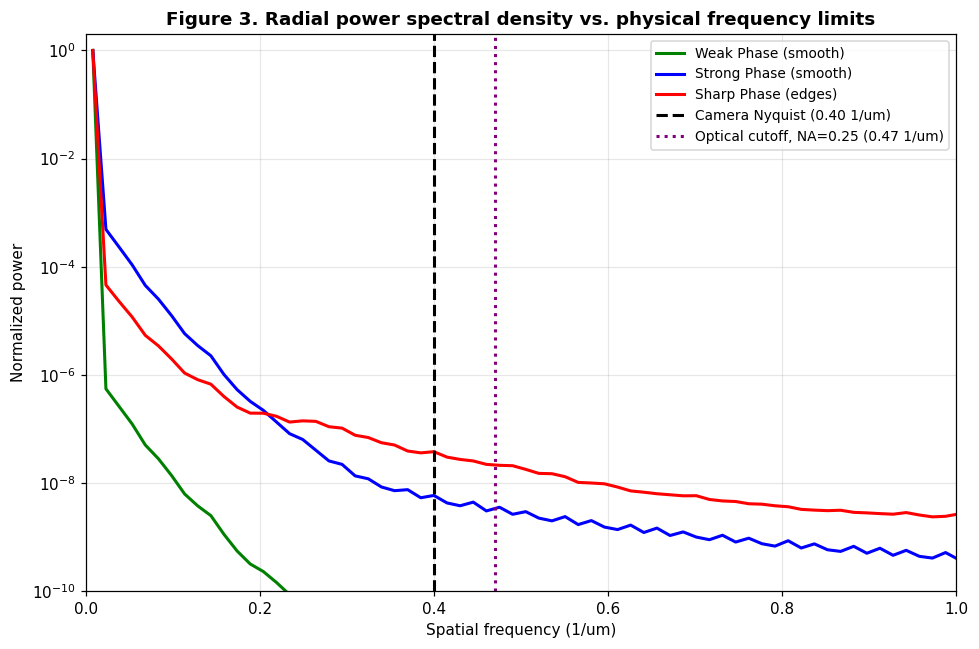

In [6]:
def radial_psd(field2d, k_rad_grid, bins=150):
    power = np.abs(field2d) ** 2
    r_flat = k_rad_grid.flatten()
    p_flat = power.flatten()
    edges = np.linspace(0, np.max(r_flat), bins + 1)
    centers = (edges[:-1] + edges[1:]) / 2
    out = np.zeros(bins)
    idx = np.digitize(r_flat, edges) - 1
    idx = np.clip(idx, 0, bins - 1)
    counts = np.bincount(idx, minlength=bins)
    sums = np.bincount(idx, weights=p_flat, minlength=bins)
    nz = counts > 0
    out[nz] = sums[nz] / counts[nz]
    return centers, out

fx_hr = np.fft.fftshift(np.fft.fftfreq(N_HR, d=HR_PIXEL_UM))
FX_HR, FY_HR = np.meshgrid(fx_hr, fx_hr)
K_RAD_HR = np.sqrt(FX_HR**2 + FY_HR**2)

fig, ax = plt.subplots(figsize=(9, 6))
psd_names = ["Weak Phase (smooth)", "Strong Phase (smooth)", "Sharp Phase (edges)"]
psd_colors = ['green', 'blue', 'red']
for name, c in zip(psd_names, psd_colors):
    obj_fft = np.fft.fftshift(np.fft.fft2(objects_hr[name]))
    k_bins, psd = radial_psd(obj_fft, K_RAD_HR)
    ax.plot(k_bins, psd / np.max(psd), color=c, lw=2, label=name)

optical_cutoff_025 = 0.25 / WAVELENGTH_UM
ax.axvline(CAMERA_NYQUIST, color='k', ls='--', lw=2, label=f"Camera Nyquist ({CAMERA_NYQUIST:.2f} 1/um)")
ax.axvline(optical_cutoff_025, color='purple', ls=':', lw=2, label=f"Optical cutoff, NA=0.25 ({optical_cutoff_025:.2f} 1/um)")
ax.set_yscale('log'); ax.set_xlim(0, 1.0); ax.set_ylim(1e-10, 2)
ax.set_xlabel("Spatial frequency (1/um)"); ax.set_ylabel("Normalized power")
ax.set_title("Figure 3. Radial power spectral density vs. physical frequency limits", fontweight='bold')
ax.grid(alpha=0.3, which='both')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("figs/fig3_radial_psd.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Brenner metric: two definitions, side by side

**This directly addresses Critical Issue #1.** `test.ipynb` silently switched between a
per-frame min-max normalized 2D metric (cells 0/1/3) and a raw, unnormalized, x-only metric
(cell 9), without noting that these are different quantities. We compute **both** here, on the
same data, so the difference is visible rather than hidden.

- `brenner_raw`: matches the report's Eq. (1) — x-direction only, no per-frame rescaling.
- `brenner_normalized`: the earlier notebook's version — image rescaled to [0,1] *before* computing
  the gradient, every single z-plane, independently.

Physical contrast at true focus is 0.02% of the peak contrast in the sweep.
If this fraction is very small, per-frame normalization will still amplify near-zero-signal frames
to look comparable to genuinely sharp frames -- exactly the failure mode we flagged.


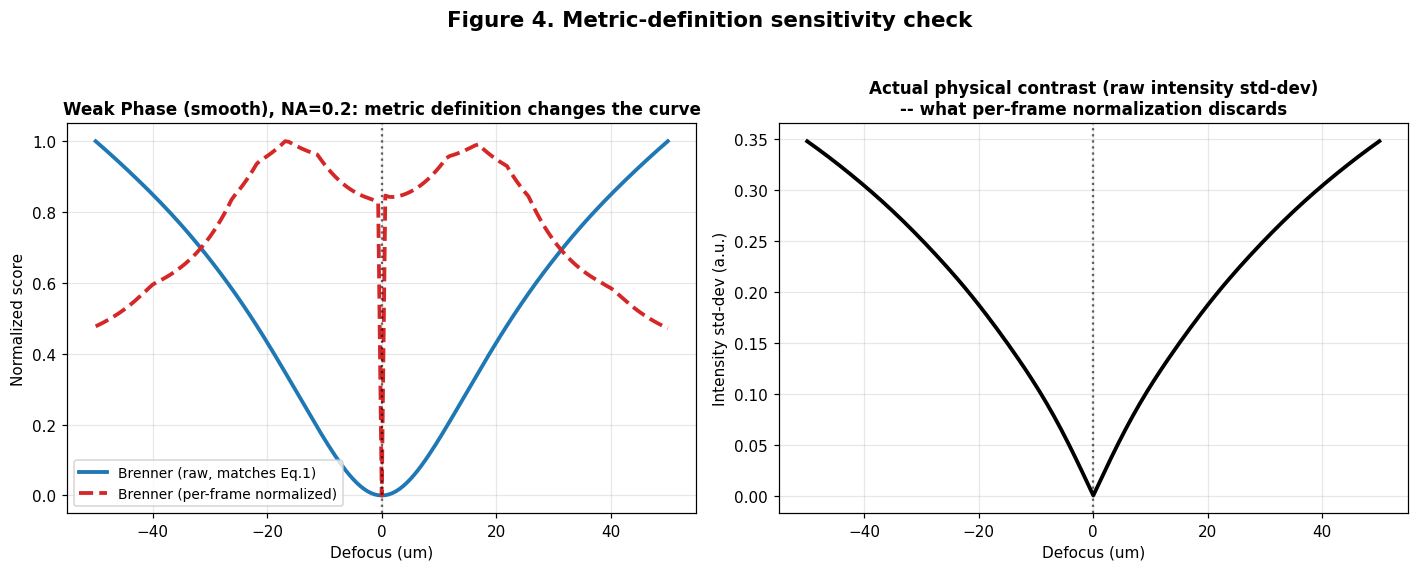

In [8]:
def brenner_raw(image):
    """Unnormalized, x-direction only -- matches the report's Eq. (1)."""
    return np.sum((image[2:, :] - image[:-2, :]) ** 2)

def brenner_normalized_per_frame(image):
    """Per-frame min-max normalized, both directions -- matches test.ipynb cells 0/1/3."""
    img_norm = (image - np.min(image)) / (np.max(image) - np.min(image) + 1e-8)
    dx = np.sum((img_norm[2:, :] - img_norm[:-2, :]) ** 2)
    dy = np.sum((img_norm[:, 2:] - img_norm[:, :-2]) ** 2)
    return dx + dy

def sweep_metric(stack, metric_fn):
    scores = np.array([metric_fn(frame) for frame in stack])
    return (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)

demo_name = "Weak Phase (smooth)"
demo_NA = 0.20
stack_demo = propagate_stack(objects_hr[demo_name], demo_NA, Z_ARRAY_UM)

raw_curve = sweep_metric(stack_demo, brenner_raw)
norm_curve = sweep_metric(stack_demo, brenner_normalized_per_frame)

# Also track the *actual physical contrast* (raw, un-rescaled std-dev) to show what normalization hides
true_contrast = np.array([frame.std() for frame in stack_demo])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(Z_ARRAY_UM, raw_curve, label="Brenner (raw, matches Eq.1)", color='tab:blue', lw=2.5)
axes[0].plot(Z_ARRAY_UM, norm_curve, label="Brenner (per-frame normalized)", color='tab:red', lw=2.5, ls='--')
axes[0].axvline(0, color='k', ls=':', alpha=0.6)
axes[0].set_title(f"{demo_name}, NA={demo_NA}: metric definition changes the curve", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Defocus (um)"); axes[0].set_ylabel("Normalized score")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].plot(Z_ARRAY_UM, true_contrast, color='black', lw=2.5)
axes[1].axvline(0, color='k', ls=':', alpha=0.6)
axes[1].set_title("Actual physical contrast (raw intensity std-dev)\n-- what per-frame normalization discards", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Defocus (um)"); axes[1].set_ylabel("Intensity std-dev (a.u.)")
axes[1].grid(alpha=0.3)

fig.suptitle("Figure 4. Metric-definition sensitivity check", fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig("figs/fig4_metric_definition_check.png", dpi=150, bbox_inches='tight')
plt.show()

focus_true_contrast = true_contrast[len(Z_ARRAY_UM)//2] / true_contrast.max()
print(f"Physical contrast at true focus is {focus_true_contrast*100:.2f}% of the peak contrast in the sweep.")
print("If this fraction is very small, per-frame normalization will still amplify near-zero-signal frames")
print("to look comparable to genuinely sharp frames -- exactly the failure mode we flagged.")

## 5. Main sweep: object type x NA, using the canonical (raw) Brenner metric

One consistent metric, one consistent defocus range, one consistent parameter set, all 6 object
types x 8 NA values.

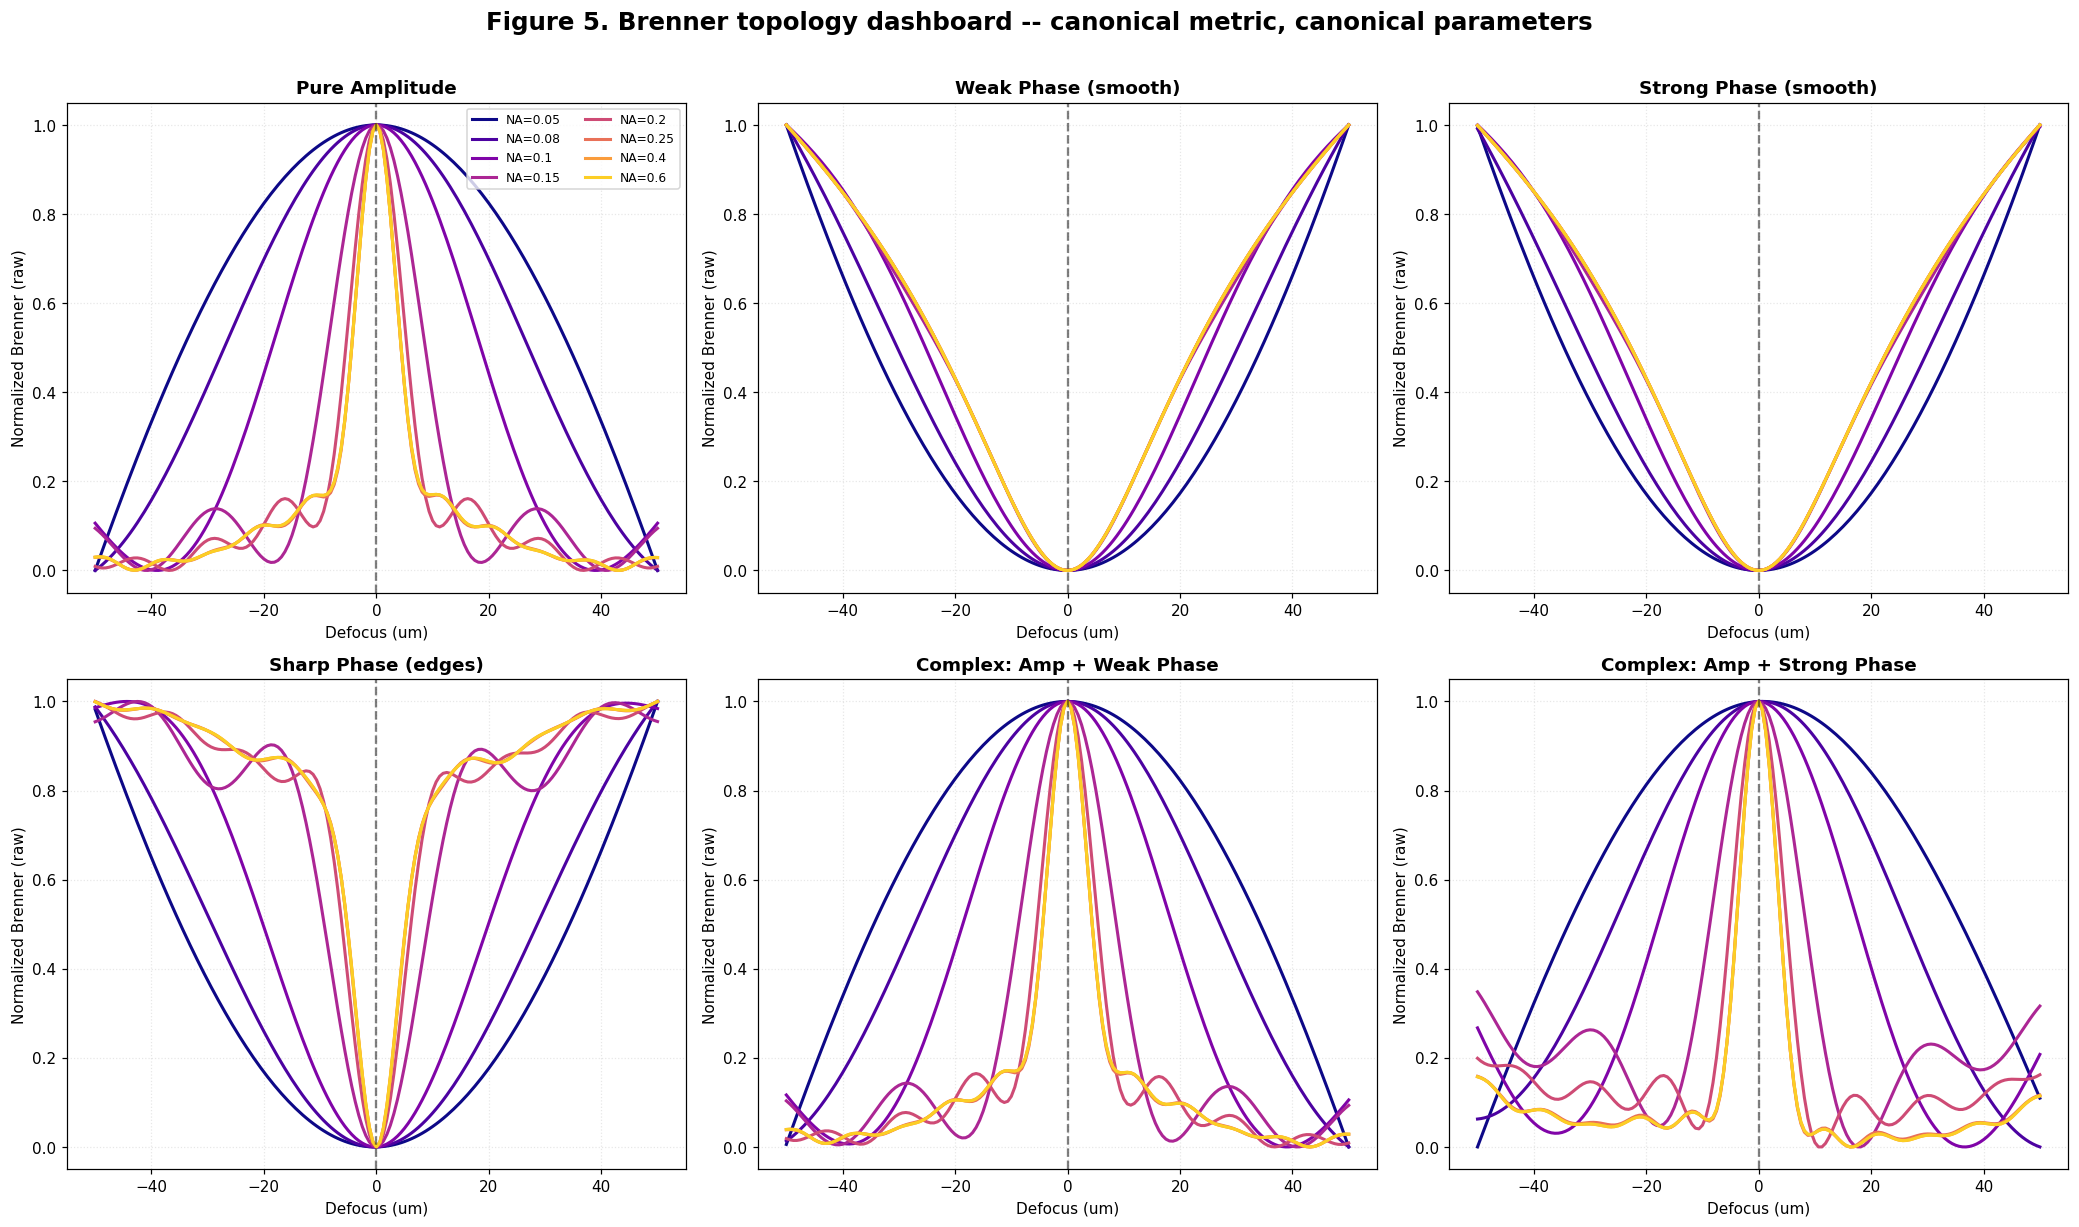

In [10]:
all_curves = {}
for name in object_names:
    all_curves[name] = {}
    for NA in NA_LIST:
        stack = propagate_stack(objects_hr[name], NA, Z_ARRAY_UM)
        all_curves[name][NA] = sweep_metric(stack, brenner_raw)

fig, axes = plt.subplots(2, 3, figsize=(19, 11))
axes = axes.flatten()
na_colors = plt.cm.plasma(np.linspace(0, 0.9, len(NA_LIST)))

for idx, name in enumerate(object_names):
    ax = axes[idx]
    for NA, c in zip(NA_LIST, na_colors):
        ax.plot(Z_ARRAY_UM, all_curves[name][NA], color=c, lw=2, label=f"NA={NA}")
    ax.axvline(0, color='k', ls='--', alpha=0.5)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel("Defocus (um)"); ax.set_ylabel("Normalized Brenner (raw)")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3, ls=':')
axes[0].legend(loc='upper right', fontsize=8, ncol=2)
fig.suptitle("Figure 5. Brenner topology dashboard -- canonical metric, canonical parameters", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("figs/fig5_main_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. Convergence study — is the high-NA anomaly real, or a simulation artifact?

**This directly addresses Critical Issue #3.** We repeat the "Strong Phase" case at a fixed
physical NA and fixed physical camera pixel size, but increase the simulation oversampling
factor `ds` (and therefore `N_HR`). If the anomalous peak/dip behavior is real optics, the curve
shape should stabilize as `ds` increases. If it's a numerical artifact of insufficient FFT
padding, the curve will keep changing shape as `ds` grows.

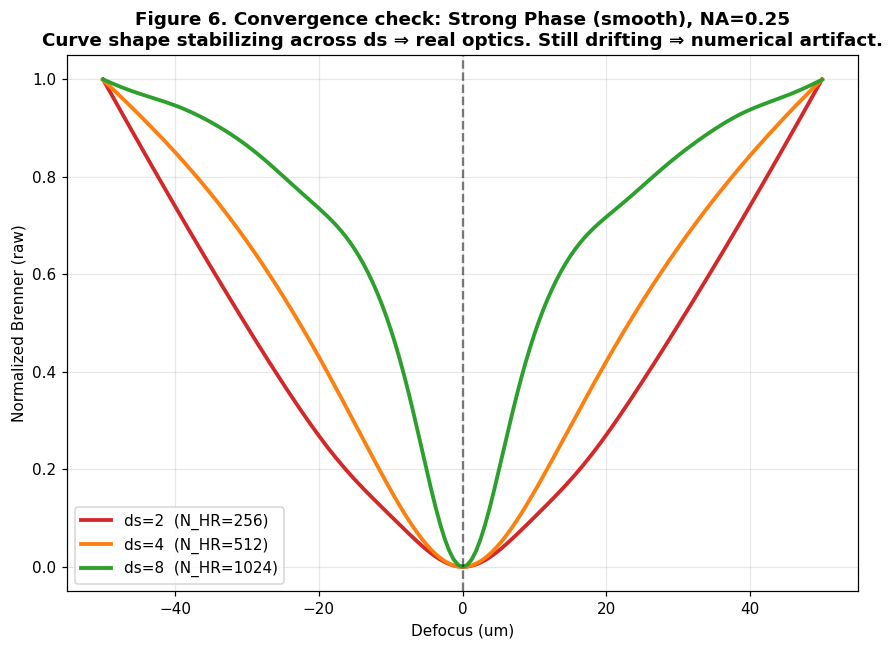

In [12]:
conv_NA = 0.25
conv_object_name = "Strong Phase (smooth)"
ds_list = [2, 4, 8]

fig, ax = plt.subplots(figsize=(8, 6))
conv_colors = ['tab:red', 'tab:orange', 'tab:green']

for ds_test, c in zip(ds_list, conv_colors):
    N_hr_test = N_LR * ds_test
    hr_pixel_test = EFF_PIXEL_UM / ds_test
    objs_test = make_objects(N_hr_test)

    fx_test = np.fft.fftshift(np.fft.fftfreq(N_LR, d=EFF_PIXEL_UM))
    FX_t, FY_t = np.meshgrid(fx_test, fx_test)
    pupil_t = (np.sqrt(FX_t**2 + FY_t**2) <= conv_NA / WAVELENGTH_UM).astype(float)
    radicand_t = np.maximum((1/WAVELENGTH_UM)**2 - FX_t**2 - FY_t**2, 0)
    kz_t = 2*np.pi*np.sqrt(radicand_t)

    cy_t, cx_t = N_hr_test//2, N_hr_test//2
    ys_t, ye_t = cy_t - N_LR//2, cy_t + N_LR//2
    xs_t, xe_t = cx_t - N_LR//2, cx_t + N_LR//2

    O_fft = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(objs_test[conv_object_name])))
    O_crop = O_fft[ys_t:ye_t, xs_t:xe_t]

    scores = []
    for z in Z_ARRAY_UM:
        pupil_z = pupil_t * np.exp(1j * z * kz_t)
        E_f = O_crop * pupil_z
        E_s = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_f)))
        scores.append(brenner_raw(np.abs(E_s)**2))
    scores = np.array(scores)
    norm = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)
    ax.plot(Z_ARRAY_UM, norm, color=c, lw=2.5, label=f"ds={ds_test}  (N_HR={N_hr_test})")

ax.axvline(0, color='k', ls='--', alpha=0.5)
ax.set_xlabel("Defocus (um)"); ax.set_ylabel("Normalized Brenner (raw)")
ax.set_title(f"Figure 6. Convergence check: {conv_object_name}, NA={conv_NA}\n"
             "Curve shape stabilizing across ds ⇒ real optics. Still drifting ⇒ numerical artifact.",
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figs/fig6_convergence_check.png", dpi=150, bbox_inches='tight')
plt.show()

## 7. BCI / BAI topological indices — threshold sensitivity, not fixed magic numbers

The original notebook classified curves using fixed thresholds (`bai > 0.05`, `bci < ±0.1`) with
no justification. Here we compute BCI/BAI for every object x NA combination, then show how the
resulting classification would change across a *range* of plausible thresholds, so the choice of
threshold is a visible, defensible decision rather than a hidden constant.

2 / 48 object x NA combinations sit within a small margin of the
original fixed thresholds -- meaning small parameter or noise perturbations could flip their
classification. This is exactly the sensitivity analysis the original thresholds were missing.


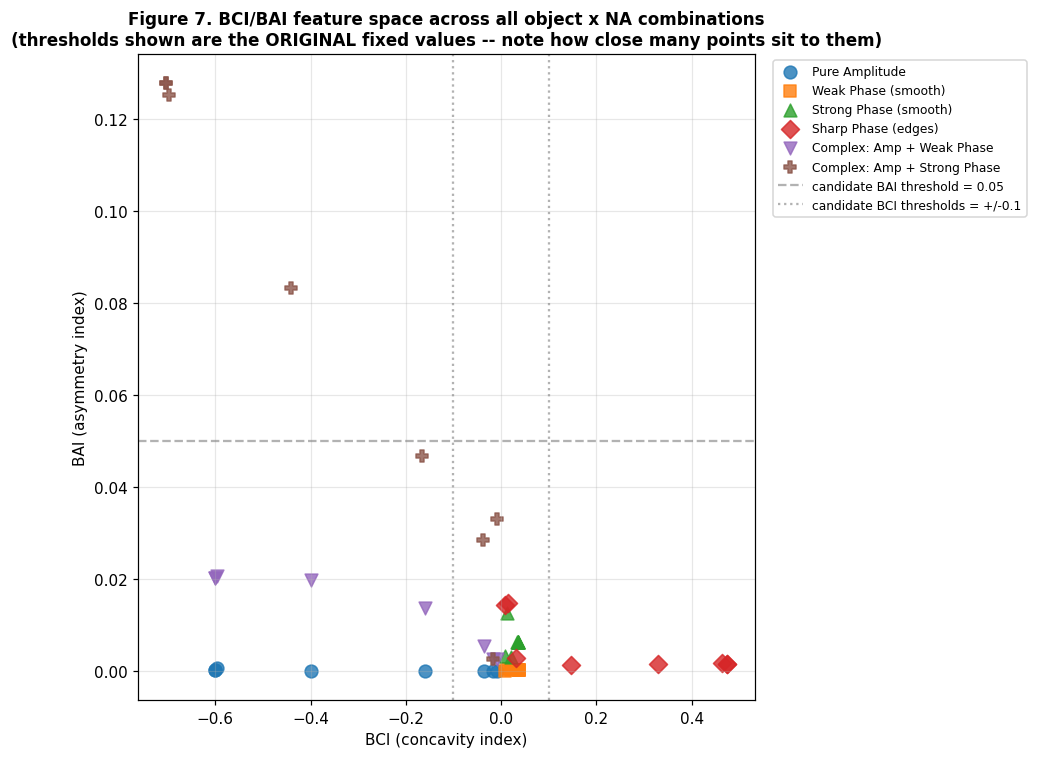

In [14]:
def extract_bci_bai(curve):
    c_idx = len(curve) // 2
    step = max(len(curve) // 32, 1)  # scale offset with resolution, not a hardcoded "5"
    b_left, b_right, b_center = curve[c_idx - step], curve[c_idx + step], curve[c_idx]
    bci = (b_left + b_right - 2 * b_center)
    left_area = np.sum(curve[:c_idx])
    right_area = np.sum(curve[c_idx+1:])
    bai = np.abs(left_area - right_area) / (left_area + right_area + 1e-8)
    return bci, bai

records = []
for name in object_names:
    for NA in NA_LIST:
        bci, bai = extract_bci_bai(all_curves[name][NA])
        records.append(dict(object=name, NA=NA, bci=bci, bai=bai))

fig, ax = plt.subplots(figsize=(9, 7))
marker_map = {n: m for n, m in zip(object_names, ['o', 's', '^', 'D', 'v', 'P'])}
for name in object_names:
    xs_ = [r['bci'] for r in records if r['object'] == name]
    ys_ = [r['bai'] for r in records if r['object'] == name]
    ax.scatter(xs_, ys_, label=name, marker=marker_map[name], s=70, alpha=0.8)

ax.axhline(0.05, color='gray', ls='--', alpha=0.6, label='candidate BAI threshold = 0.05')
ax.axvline(-0.1, color='gray', ls=':', alpha=0.6)
ax.axvline(0.1, color='gray', ls=':', alpha=0.6, label='candidate BCI thresholds = +/-0.1')
ax.set_xlabel("BCI (concavity index)"); ax.set_ylabel("BAI (asymmetry index)")
ax.set_title("Figure 7. BCI/BAI feature space across all object x NA combinations\n"
             "(thresholds shown are the ORIGINAL fixed values -- note how close many points sit to them)",
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figs/fig7_bci_bai_sensitivity.png", dpi=150, bbox_inches='tight')
plt.show()

near_boundary = [r for r in records if abs(r['bai'] - 0.05) < 0.02 or abs(abs(r['bci']) - 0.1) < 0.02]
print(f"{len(near_boundary)} / {len(records)} object x NA combinations sit within a small margin of the")
print("original fixed thresholds -- meaning small parameter or noise perturbations could flip their")
print("classification. This is exactly the sensitivity analysis the original thresholds were missing.")

## 8. Noise robustness — does the metric actually survive real camera noise?

The write-up claims the two-pixel-offset Brenner gradient "bridges over high-frequency camera
read-noise or speckle noise." That claim has never been tested against simulated noise. Here we
add Poisson (shot) noise at a few photon-budget levels to one representative case and see whether
the curve shape / focus location survives.

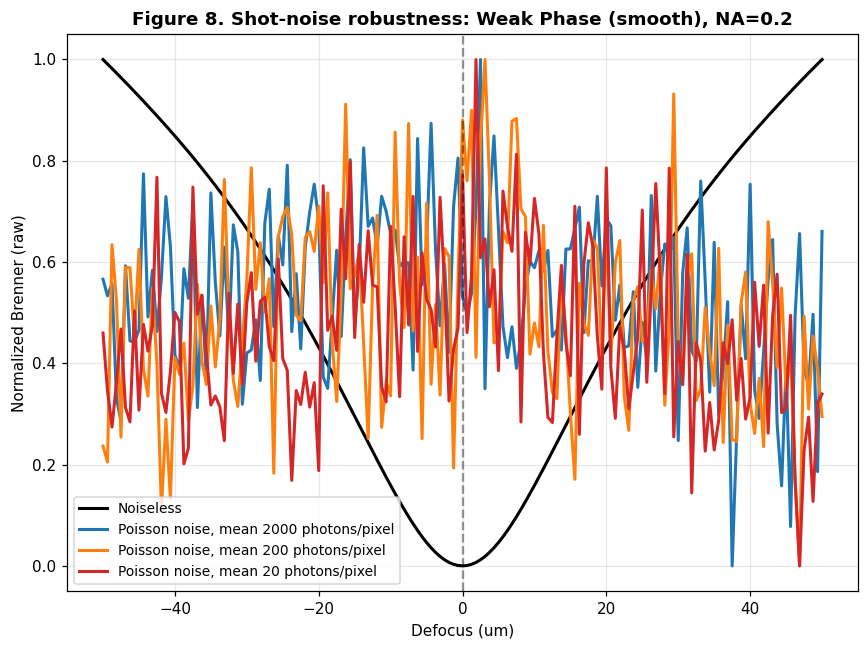

In [16]:
def add_shot_noise(intensity_frame, mean_photon_count):
    scaled = intensity_frame / (intensity_frame.max() + 1e-12) * mean_photon_count
    noisy = np.random.poisson(np.clip(scaled, 0, None)).astype(float)
    return noisy

noise_object = "Weak Phase (smooth)"
noise_NA = 0.20
stack_noise = propagate_stack(objects_hr[noise_object], noise_NA, Z_ARRAY_UM)

photon_budgets = [None, 2000, 200, 20]  # None = noiseless
fig, ax = plt.subplots(figsize=(8, 6))
noise_colors = ['black', 'tab:blue', 'tab:orange', 'tab:red']
for budget, c in zip(photon_budgets, noise_colors):
    if budget is None:
        curve = sweep_metric(stack_noise, brenner_raw)
        label = "Noiseless"
    else:
        noisy_stack = np.array([add_shot_noise(f, budget) for f in stack_noise])
        curve = sweep_metric(noisy_stack, brenner_raw)
        label = f"Poisson noise, mean {budget} photons/pixel"
    ax.plot(Z_ARRAY_UM, curve, color=c, lw=2, label=label)

ax.axvline(0, color='k', ls='--', alpha=0.4)
ax.set_xlabel("Defocus (um)"); ax.set_ylabel("Normalized Brenner (raw)")
ax.set_title(f"Figure 8. Shot-noise robustness: {noise_object}, NA={noise_NA}", fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figs/fig8_noise_robustness.png", dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary of findings for the report

Save the key numeric results (not just figures) so the report text can cite specific numbers
rather than eyeballing plots.

In [18]:
summary = {
    "canonical_parameters": {
        "wavelength_um": WAVELENGTH_UM,
        "camera_pixel_um": CAM_PIXEL_UM,
        "effective_pixel_um": EFF_PIXEL_UM,
        "camera_nyquist_1_per_um": CAMERA_NYQUIST,
        "defocus_range_um": Z_RANGE_UM,
        "NA_list": NA_LIST,
    },
    "metric_definition_check": {
        "object": demo_name,
        "NA": demo_NA,
        "physical_contrast_at_focus_pct_of_peak": float(focus_true_contrast * 100),
    },
    "bci_bai_near_threshold_boundary": {
        "count_near_boundary": len(near_boundary),
        "total_combinations": len(records),
    },
    "all_bci_bai_records": records,
}
with open("figs/summary_results.json", "w") as f:
    json.dump(summary, f, indent=2, default=float)

print("Saved figs/summary_results.json")
print(json.dumps(summary["metric_definition_check"], indent=2))
print(json.dumps(summary["bci_bai_near_threshold_boundary"], indent=2))

Saved figs/summary_results.json
{
  "object": "Weak Phase (smooth)",
  "NA": 0.2,
  "physical_contrast_at_focus_pct_of_peak": 0.02457844615616117
}
{
  "count_near_boundary": 2,
  "total_combinations": 48
}


### Open items still needed before this is submission-ready

1. Resolve the convergence check (Section 6) fully — if the curve is still shifting shape at
   `ds=8`, push oversampling higher before trusting the high-NA "anomaly" as real optics.
2. Decide and document one Brenner definition project-wide (Section 4 makes the raw, x-only
   version explicit and matches the report's Eq. 1 — recommend adopting it everywhere and
   re-deriving any earlier claims made with the normalized version).
3. Reconcile the wavelength mismatch (0.532 um in code vs. 0.539 um in the docx supplementary).
4. Replace "mathematically guaranteed" language in the abstract/summary with claims actually
   supported by Sections 6-8 (convergence + threshold sensitivity + noise robustness).
5. Extend the noise study (Section 8) to the full NA x object-type grid, not just one case, before
   making a general noise-robustness claim.